# Imputation Benchmark

**Purpose.** Compare Raw, Tangram, gimVI, and REVISE expression profiles using reconstruction metrics and cell-type-conditional Moran statistics for spatial continuity.

**Inputs.** Use `selected_xenium.h5ad` for each part, the combined `results/imputation/adata_sp_impute.h5ad` REVISE reconstruction, and part-specific `Tangram_impute.csv` and `gimVI_impute.csv` files. The preparation section creates `REVISE_impute.h5ad` for each part.

### Two ways to obtain the analysis inputs

1. **Reconstruct locally.** Download the Sim2Real-ST inputs and complete the Tangram, gimVI, and REVISE imputation workflows for parts 1–3, using the paths declared below. The Raw comparison is read directly from each reference H5AD.
2. **Start from released results.** Download [`Sim2Real-ST.zip` and `Result.zip`](https://zenodo.org/records/17705737), then place the extracted files under the raw-data and result directories declared in the configuration section.

Both routes must provide all listed method outputs before metric calculation begins.

After completing either path, run this notebook from top to bottom.

## 1. Configuration

Define the repository contract, benchmark cases, method names, metric names, and output directories.

In [ ]:
# [CONFIG] Imports
from pathlib import Path
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import squidpy as sq

from revise.analysis.metrics import compute_metric

warnings.simplefilter(action="ignore", category=FutureWarning)

In [ ]:
# [CONFIG] Paths, cases, methods, metrics, and output folders
source_path = "../.."
task = "imputation"
parts = ["part3", "part1", "part2"]
methods = ["REVISE", "Raw", "Tangram", "gimVI"]
metrics = ["PCC", "SSIM", "MSE"]
cell_type_col = "Level1"

sim2real_data_path = f"{source_path}/raw_data/Sim2Real-ST/imputation"
result_path = f"{source_path}/results/imputation"
combined_revise_path = f"{result_path}/adata_sp_impute.h5ad"
output_path = f"{source_path}/output/imputation_benchmark"
metric_output_path = f"{output_path}/metric_result"
spatial_output_path = f"{output_path}/plot_imputation"

Path(metric_output_path).mkdir(parents=True, exist_ok=True)
Path(f"{metric_output_path}/mean").mkdir(parents=True, exist_ok=True)
Path(spatial_output_path).mkdir(parents=True, exist_ok=True)

baseline_files = {
    "Tangram": "Tangram_impute.csv",
    "gimVI": "gimVI_impute.csv",
}

method_colors = {
    "REVISE": "#1f77b4",
    "Raw": "#7f7f7f",
    "Tangram": "#2ca02c",
    "gimVI": "#d62728",
}

## 2. Input preparation and axis alignment

Split the combined REVISE reconstruction with the declared spatial windows, align each subset to reference cell IDs, and save one `REVISE_impute.h5ad` per part. Tangram and gimVI CSV files are assembled as in-memory AnnData objects with reference observations and spatial coordinates; no baseline H5AD files are written.

In [ ]:
# [DEFINE] Input paths, spatial windows, and basic loaders
PART_BOUNDS = {
    "part1": {"x": (42000, 52000), "y": (8000, 13000)},
    "part2": {"x": (52000, 57000), "y": (13000, 23000)},
    "part3": {"x": (60000, 65000), "y": (10000, 20000)},
}


def reference_path(part):
    return f"{sim2real_data_path}/{part}/selected_xenium.h5ad"


def revise_part_path(part):
    return f"{result_path}/{part}/REVISE_impute.h5ad"


def baseline_expression_path(method, part):
    return f"{result_path}/{part}/{baseline_files[method]}"


def _canonicalize_gene_names(adata):
    work = adata.copy()
    gene_names = pd.Index([str(gene).upper() for gene in work.var_names])
    if gene_names.has_duplicates:
        raise ValueError("gene names are duplicated after upper-casing")
    work.var_names = gene_names
    return work


def load_reference(part):
    return _canonicalize_gene_names(sc.read_h5ad(reference_path(part)))


def subset_revise_by_window(combined, part):
    bounds = PART_BOUNDS[part]
    spatial = np.asarray(combined.obsm["spatial"])
    mask = (
        (spatial[:, 0] >= bounds["x"][0])
        & (spatial[:, 0] <= bounds["x"][1])
        & (spatial[:, 1] >= bounds["y"][0])
        & (spatial[:, 1] <= bounds["y"][1])
    )
    return combined[mask].copy()

In [ ]:
# [DEFINE] Part preparation, baseline assembly, and axis alignment
def _ordered_overlap(reference_names, candidate_names):
    candidate_set = set(candidate_names)
    return pd.Index([name for name in reference_names if name in candidate_set])


def prepare_revise_parts():
    combined = _canonicalize_gene_names(sc.read_h5ad(combined_revise_path))
    for part in parts:
        reference = load_reference(part)
        prediction = subset_revise_by_window(combined, part)
        cell_names = _ordered_overlap(reference.obs_names, prediction.obs_names)
        if len(cell_names) == 0:
            raise ValueError(f"{part} has no shared cells between the reference and REVISE output")

        prediction = prediction[cell_names].copy()
        reference_aligned = reference[cell_names]
        prediction.obs = reference_aligned.obs.copy()
        prediction.obsm["spatial"] = np.asarray(
            reference_aligned.obsm["spatial"]
        ).copy()

        destination = Path(revise_part_path(part))
        destination.parent.mkdir(parents=True, exist_ok=True)
        prediction.write_h5ad(destination)
        print(f"Saved aligned REVISE input: {destination}")


def load_baseline_expression(method, part):
    expression = pd.read_csv(baseline_expression_path(method, part), index_col=0)
    expression.columns = pd.Index(
        [str(gene).upper() for gene in expression.columns]
    )
    if expression.columns.has_duplicates:
        raise ValueError(
            f"{method} gene names are duplicated after upper-casing for {part}"
        )

    reference = load_reference(part)
    cell_names = _ordered_overlap(reference.obs_names, expression.index)
    if len(cell_names) == 0:
        raise ValueError(f"{method} and the reference have no overlapping cells for {part}")

    reference_aligned = reference[cell_names]
    prediction = ad.AnnData(
        X=expression.loc[cell_names].to_numpy(),
        obs=reference_aligned.obs.copy(),
        var=pd.DataFrame(index=expression.columns.copy()),
    )
    prediction.obsm["spatial"] = np.asarray(
        reference_aligned.obsm["spatial"]
    ).copy()
    return prediction


def load_method_expression(method, part):
    if method == "Raw":
        return load_reference(part)
    if method == "REVISE":
        return _canonicalize_gene_names(sc.read_h5ad(revise_part_path(part)))
    if method in baseline_files:
        return load_baseline_expression(method, part)
    raise ValueError(f"Unknown imputation method: {method}")


def align_expression(reference, prediction):
    reference = _canonicalize_gene_names(reference)
    prediction = _canonicalize_gene_names(prediction)
    cell_names = _ordered_overlap(reference.obs_names, prediction.obs_names)
    gene_names = _ordered_overlap(reference.var_names, prediction.var_names)

    if len(cell_names) == 0:
        raise ValueError("reference and prediction have no overlapping cells")
    if len(gene_names) == 0:
        raise ValueError("reference and prediction have no overlapping genes")

    reference_aligned = reference[cell_names, gene_names].copy()
    prediction_aligned = prediction[cell_names, gene_names].copy()
    if reference_aligned.shape != prediction_aligned.shape:
        raise ValueError("aligned reference and prediction shapes differ")
    return reference_aligned, prediction_aligned


def make_spatial_adata(reference, prediction):
    reference_aligned, prediction_aligned = align_expression(
        reference, prediction
    )
    prediction_aligned.obs = reference_aligned.obs.copy()
    prediction_aligned.obsm["spatial"] = np.asarray(
        reference_aligned.obsm["spatial"]
    ).copy()
    return prediction_aligned

In [ ]:
# [PREPARE] Split and align the combined REVISE reconstruction
prepare_revise_parts()

In [ ]:
# [OUTPUT] The displayed output is a preserved historical snapshot; rerun this cell to refresh it.
reference = load_reference(parts[1])
reference


AnnData object with n_obs × n_vars = 242294 × 371
    obs: 'x', 'y', 'Level1', 'max_score', 'cluster_subtype', 'sp_leiden_0.2', 'sp_leiden_0.4', 'sp_leiden_0.6', 'sp_leiden_0.8', 'sp_leiden_1.0', 'spatial_score_0.2', 'spatial_score_0.4', 'spatial_score_0.6', 'spatial_score_0.8', 'spatial_score_1.0', 'batch'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    obsm: 'Level1', 'X_pca', 'cluster_subtype', 'spatial'

## 3. Expression reconstruction metrics

Align shared cells and genes, compute PCC, SSIM, and MSE, save per-gene and mean tables, and plot the method comparison.

In [ ]:
# [DEFINE] Helper functions.
def _metric_table(metrics_df, method, part):
    result = metrics_df.copy()
    if "Gene" not in result.columns:
        result = result.rename_axis("Gene").reset_index()
    result["Gene"] = result["Gene"].astype(str).str.upper()

    missing_metrics = [metric for metric in metrics if metric not in result.columns]
    if missing_metrics:
        raise KeyError(f"missing expression metrics: {missing_metrics}")

    result = result[["Gene", *metrics]].copy()
    result["Method"] = method
    result["Part"] = part
    return result.melt(
        id_vars=["Gene", "Method", "Part"],
        value_vars=metrics,
        var_name="Metric",
        value_name="Value",
    )


def compute_expression_results(part):
    reference = load_reference(part)
    result_frames = []
    for method in methods:
        prediction = load_method_expression(method, part)
        reference_aligned, prediction_aligned = align_expression(
            reference, prediction
        )
        metrics_df = compute_metric(
            reference_aligned,
            prediction_aligned,
            adata_process=False,
            gene_list=None,
            normalize=False,
        )
        result_frames.append(_metric_table(metrics_df, method, part))
    return pd.concat(result_frames, ignore_index=True)


In [ ]:
# [DEFINE] Helper functions.
def plot_expression_metrics(metrics_df, metric, ax):
    plot_df = metrics_df.loc[metrics_df["Metric"] == metric]
    sns.boxplot(
        data=plot_df,
        x="Method",
        y="Value",
        order=methods,
        hue="Method",
        palette=method_colors,
        legend=False,
        showfliers=False,
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    if metric == "MSE":
        ax.set_yscale("log")


In [ ]:
# [OUTPUT] The displayed output is a preserved historical snapshot; rerun this cell to refresh it.
expression_part1 = compute_expression_results("part1")
expression_part1.head()


PCC: 0.6439, 0.9967, -0.0147
SSIM: 0.5704, 0.9775, 0.0007
MSE: 3.3091, 113.9965, 0.0033
NRMSE: 5.1519, 51.9243, 1.1486
PCC: 0.3155, 0.8680, -0.0081
SSIM: 0.5228, 0.9650, 0.0032
MSE: 3.9197, 328.7172, 0.0039
NRMSE: 6.3128, 118.4860, 0.8817
PCC: 0.3282, 0.8609, -0.0074
SSIM: 0.5046, 0.9716, 0.0105
MSE: 3.2593, 122.1086, 0.0036
NRMSE: 5.2229, 40.6589, 1.1636
PCC: 0.2984, 0.8607, 0.0086
SSIM: 0.3553, 0.9056, 0.0048
MSE: 4.5161, 487.8483, 0.0041
NRMSE: 7.0964, 96.2009, 0.8298


,Gene,PCC_type,PCC,SSIM,MSE,NRMSE
0,RGS13,Accuracy,0.980115,0.868083,0.019885,7.091472
1,CREB3L1,Accuracy,0.699531,0.080116,0.300469,1.824317
2,SIT1,Accuracy,0.972856,0.825724,0.027144,6.069697
3,FYB1,PCC,0.303029,0.626522,0.104794,3.878170
4,LEF1,Accuracy,0.720248,0.096682,0.279752,1.890660
...,...,...,...,...,...,...
359,TUBB,PCC,0.329630,0.037109,11.660366,1.503485
360,UGT2B17,Accuracy,0.981173,0.875268,0.018827,7.288104
361,CD7,PCC,0.018603,0.953989,0.006729,23.585845
362,SERPINA1,PCC,0.437629,0.727453,0.432860,3.753951


In [ ]:
# [RUN] Compute and save expression reconstruction metrics
expression_results = pd.concat(
    [compute_expression_results(part) for part in parts],
    ignore_index=True,
)

expression_means = []
for part in parts:
    part_results = expression_results.loc[expression_results["Part"] == part]
    for metric in metrics:
        metric_results = part_results.loc[
            part_results["Metric"] == metric,
            ["Method", "Value", "Part", "Metric", "Gene"],
        ]
        metric_results.to_csv(
            f"{metric_output_path}/{part}_{metric}.csv", index=False
        )

    means = (
        part_results.groupby(["Method", "Metric"], as_index=False)["Value"]
        .mean()
        .pivot(index="Method", columns="Metric", values="Value")
        .reindex(columns=metrics)
        .reset_index()
    )
    means.to_csv(f"{metric_output_path}/mean/{part}.csv", index=False)
    expression_means.append(means.assign(Part=part))

expression_summary = pd.concat(expression_means, ignore_index=True)
expression_summary.to_csv(
    f"{output_path}/expression_mean_summary.csv", index=False
)


PCC: 0.6348, 0.9975, -0.0145
SSIM: 0.5579, 0.9828, 0.0000
MSE: 4.8763, 655.5229, 0.0025
NRMSE: 5.3655, 75.8219, 0.8544
PCC: 0.3895, 0.8912, 0.0538
SSIM: 0.2903, 0.8368, 0.0083
MSE: 1.2615, 39.4779, 0.0084
NRMSE: 5.5210, 40.9899, 0.6670
PCC: 0.3121, 0.8606, 0.0222
SSIM: 0.2417, 0.8429, 0.0038
MSE: 1.5931, 60.2162, 0.0094
NRMSE: 6.1680, 54.1951, 0.6957
PCC: 0.3334, 0.8910, 0.0129
SSIM: 0.3064, 0.8433, 0.0106
MSE: 0.8249, 12.5999, 0.0066
NRMSE: 5.4156, 36.2690, 0.3886


/tmp/ipykernel_2735863/390962426.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Method', y='Values', data=data,
/tmp/ipykernel_2735863/390962426.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Method', y='Values', data=data,
/tmp/ipykernel_2735863/390962426.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Method', y='Values', data=data,


PCC: 0.6439, 0.9967, -0.0147
SSIM: 0.5707, 0.9772, 0.0013
MSE: 3.3091, 113.9965, 0.0033
NRMSE: 5.1519, 51.9243, 1.1486
PCC: 0.3155, 0.8680, -0.0081
SSIM: 0.5230, 0.9648, 0.0047
MSE: 3.9197, 328.7172, 0.0039
NRMSE: 6.3128, 118.4860, 0.8817
PCC: 0.3282, 0.8609, -0.0074
SSIM: 0.5053, 0.9716, 0.0115
MSE: 3.2593, 122.1086, 0.0036
NRMSE: 5.2229, 40.6589, 1.1636
PCC: 0.2984, 0.8607, 0.0086
SSIM: 0.3559, 0.9064, 0.0051
MSE: 4.5161, 487.8483, 0.0041
NRMSE: 7.0964, 96.2009, 0.8298


/tmp/ipykernel_2735863/390962426.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Method', y='Values', data=data,
/tmp/ipykernel_2735863/390962426.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Method', y='Values', data=data,
/tmp/ipykernel_2735863/390962426.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Method', y='Values', data=data,


PCC: 0.6206, 0.9981, -0.0057
SSIM: 0.5764, 0.9870, 0.0027
MSE: 11.7741, 2348.8922, 0.0019
NRMSE: 5.7585, 117.2562, 1.0196
PCC: 0.4732, 0.9132, 0.0430
SSIM: 0.3582, 0.9096, 0.0083
MSE: 0.9787, 56.8504, 0.0080
NRMSE: 5.1758, 51.8943, 0.6624
PCC: 0.3834, 0.9032, 0.0157
SSIM: 0.3099, 0.9030, 0.0048
MSE: 1.3306, 102.5301, 0.0088
NRMSE: 5.5451, 54.3998, 0.8522
PCC: 0.4071, 0.8849, 0.0086
SSIM: 0.3866, 0.9303, 0.0124
MSE: 0.6919, 28.6303, 0.0061
NRMSE: 5.0468, 45.2597, 0.4414


/tmp/ipykernel_2735863/390962426.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Method', y='Values', data=data,
/tmp/ipykernel_2735863/390962426.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Method', y='Values', data=data,
/tmp/ipykernel_2735863/390962426.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Method', y='Values', data=data,


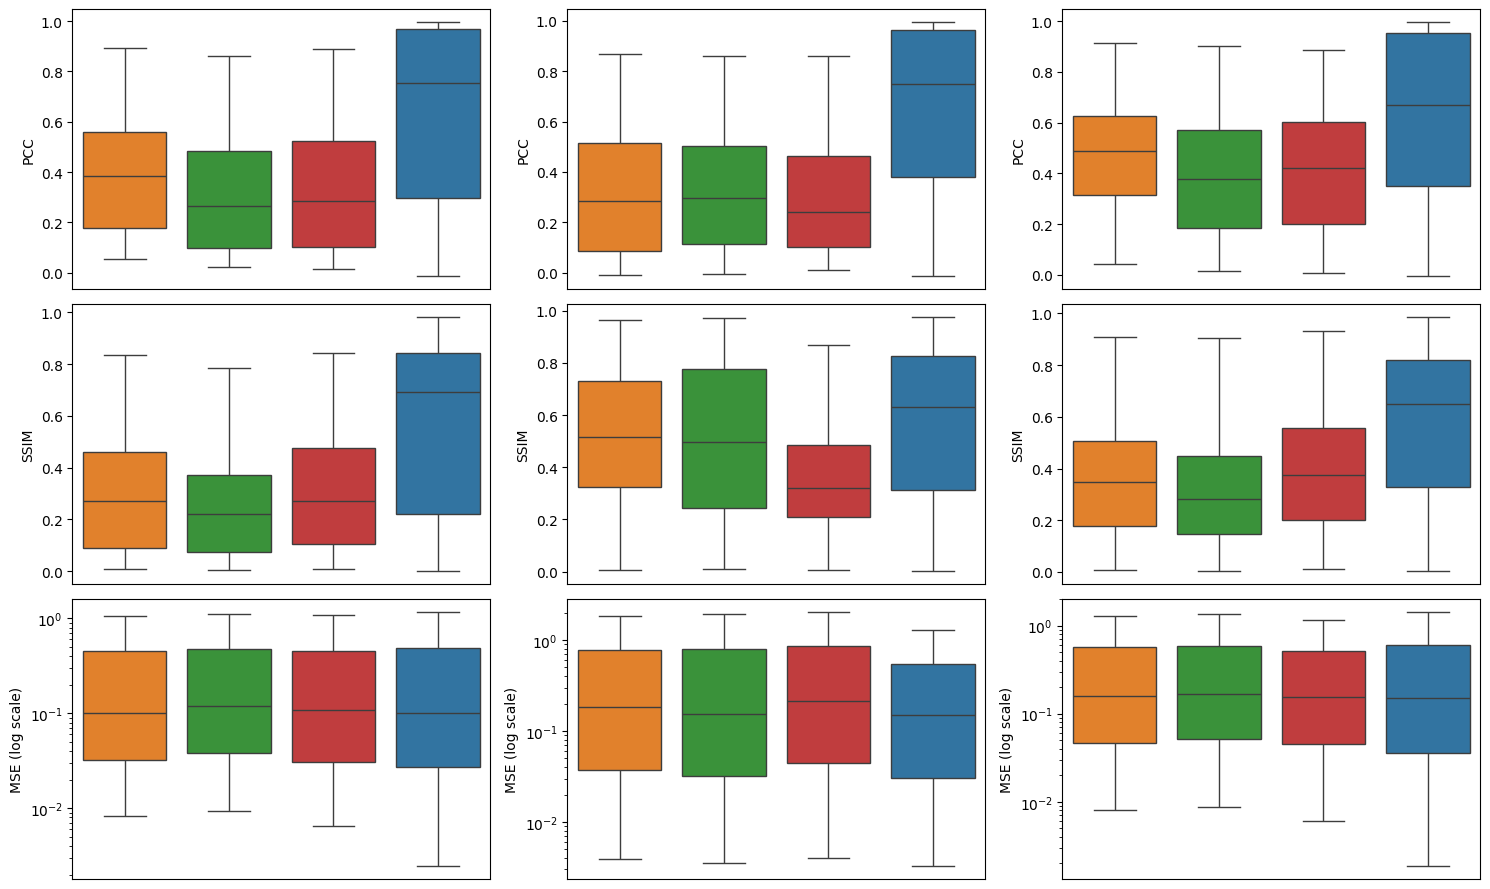

In [ ]:
# [OUTPUT] The displayed output is a preserved historical snapshot; rerun this cell to refresh it.
fig, axes = plt.subplots(len(metrics), len(parts), figsize=(15, 9), squeeze=False)
for column, part in enumerate(parts):
    part_results = expression_results.loc[expression_results["Part"] == part]
    for row, metric in enumerate(metrics):
        plot_expression_metrics(part_results, metric, axes[row, column])
        axes[row, column].set_title(part)
fig.tight_layout()
fig.savefig(f"{output_path}/analysis_major_CF_panel.pdf", dpi=300)
plt.show()


## 4. Conditional Moran and spatial continuity

Compute `I_same` and `I_diff` with cell-type-aware spatial connectivity. These columns retain compatibility with the historical MISC/MIDC outputs.

In [ ]:
# [DEFINE] Helper functions.
def compute_conditional_moran(adata, cell_type_col=cell_type_col):
    work = adata.copy()
    sc.pp.normalize_total(work, target_sum=1e4)
    sc.pp.log1p(work)

    sq.gr.spatial_neighbors(work)
    connectivity = work.obsp["spatial_connectivities"].tocoo()
    labels = work.obs[cell_type_col].to_numpy()

    same_mask = labels[connectivity.row] == labels[connectivity.col]
    diff_mask = ~same_mask
    same_connectivity = connectivity.copy()
    diff_connectivity = connectivity.copy()
    same_connectivity.data[~same_mask] = 0
    diff_connectivity.data[~diff_mask] = 0
    work.obsp["spatial_connectivities_same"] = same_connectivity.tocsr()
    work.obsp["spatial_connectivities_diff"] = diff_connectivity.tocsr()

    sq.gr.spatial_autocorr(
        work,
        connectivity_key="spatial_connectivities_same",
        mode="moran",
        genes=work.var_names,
        n_perms=1,
        n_jobs=1,
    )
    same = work.uns["moranI"]["I"].loc[work.var_names].rename("I_same")
    same = same.mask((same >= 1) | (same <= -1))

    sq.gr.spatial_autocorr(
        work,
        connectivity_key="spatial_connectivities_diff",
        mode="moran",
        genes=work.var_names,
        n_perms=1,
        n_jobs=1,
    )
    diff = work.uns["moranI"]["I"].loc[work.var_names].rename("I_diff")
    diff = diff.mask((diff >= 1) | (diff <= -1))

    return pd.concat([same, diff], axis=1)


In [ ]:
# [DEFINE] Helper functions.
def compute_spatial_results(part):
    reference = load_reference(part)
    result_frames = []
    for method in methods:
        prediction = load_method_expression(method, part)
        spatial_adata = make_spatial_adata(reference, prediction)
        moran = compute_conditional_moran(spatial_adata, cell_type_col)
        moran.to_csv(f"{spatial_output_path}/{method}_{part}.csv")
        result_frames.append(
            moran.reset_index()
            .rename(columns={"index": "Gene"})
            .assign(Method=method, Part=part)
        )
    return pd.concat(result_frames, ignore_index=True)


In [ ]:
# [DEFINE] Helper functions.
def plot_conditional_moran(summary_df, part, ax):
    part_summary = summary_df.loc[summary_df["Part"] == part].set_index("Method")
    positions = np.arange(len(methods))
    width = 0.8

    for position, method in enumerate(methods):
        row = part_summary.loc[method]
        ax.bar(
            positions[position],
            row["I_same_mean"],
            width,
            color=method_colors[method],
            yerr=2 * row["I_same_sem"],
            capsize=5,
        )
        ax.bar(
            positions[position],
            -row["I_diff_mean"],
            width,
            color=method_colors[method],
            yerr=2 * row["I_diff_sem"],
            capsize=5,
            alpha=0.5,
        )

    ax.axhline(0, color="black", linewidth=1)
    ax.set_xticks(positions, methods, rotation=45, ha="right")
    ax.set_ylim(-0.5, 1)
    ax.set_title(part)
    ax.set_ylabel("I_same / -I_diff")
    ax.grid(axis="y", linestyle="--", alpha=0.3)


In [ ]:
# [OUTPUT] The displayed output is a preserved historical snapshot; rerun this cell to refresh it.
spatial_reference = load_reference("part1")
gimvi_prediction = load_method_expression("gimVI", "part1")
gimvi_spatial = make_spatial_adata(spatial_reference, gimvi_prediction)
gimvi_spatial


AnnData object with n_obs × n_vars = 13952 × 377
    obs: 'cell_id', 'x', 'y', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'x_old', 'y_old', 'Level1'
    obsm: 'spatial'

In [ ]:
# [OUTPUT] The displayed output is a preserved historical snapshot; rerun this cell to refresh it.
revise_prediction = load_method_expression("REVISE", "part1")
revise_spatial = make_spatial_adata(spatial_reference, revise_prediction)
revise_spatial


AnnData object with n_obs × n_vars = 242294 × 371
    obs: 'x', 'y', 'Level1', 'max_score', 'cluster_subtype', 'sp_leiden_0.2', 'sp_leiden_0.4', 'sp_leiden_0.6', 'sp_leiden_0.8', 'sp_leiden_1.0', 'spatial_score_0.2', 'spatial_score_0.4', 'spatial_score_0.6', 'spatial_score_0.8', 'spatial_score_1.0', 'batch'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    obsm: 'Level1', 'X_pca', 'cluster_subtype', 'spatial'

View of AnnData object with n_obs × n_vars = 13226 × 371
    obs: 'x', 'y', 'Level1', 'max_score', 'cluster_subtype', 'sp_leiden_0.2', 'sp_leiden_0.4', 'sp_leiden_0.6', 'sp_leiden_0.8', 'sp_leiden_1.0', 'spatial_score_0.2', 'spatial_score_0.4', 'spatial_score_0.6', 'spatial_score_0.8', 'spatial_score_1.0', 'batch'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    obsm: 'Level1', 'X_pca', 'cluster_subtype', 'spatial'

In [ ]:
# [OUTPUT] The displayed output is a preserved historical snapshot; rerun this cell to refresh it.
moranI = compute_conditional_moran(gimvi_spatial, cell_type_col=cell_type_col)
moranI


  0%|          | 0/1 [00:00<?, ?/s]

  0%|          | 0/1 [00:00<?, ?/s]

,I_same,I_diff
SCG5,0.377688,-0.056536
IL32,0.367016,0.094861
ODF2L,0.505686,-0.129923
HPGDS,0.441247,0.534759
RORA,0.839820,0.592549
...,...,...
C1QC,0.490366,0.507776
DKK1,0.620757,0.115991
CST7,0.537041,-0.000046
LRMP,0.892155,0.559020


In [ ]:
# [RUN] Compute and save conditional Moran results
spatial_results = pd.concat(
    [compute_spatial_results(part) for part in parts],
    ignore_index=True,
)

spatial_summary = (
    spatial_results.groupby(["Part", "Method"], as_index=False)
    .agg(
        I_same_mean=("I_same", "mean"),
        I_same_sem=("I_same", "sem"),
        I_diff_mean=("I_diff", "mean"),
        I_diff_sem=("I_diff", "sem"),
    )
    .reindex(
        columns=[
            "Part",
            "Method",
            "I_same_mean",
            "I_same_sem",
            "I_diff_mean",
            "I_diff_sem",
        ]
    )
)
spatial_summary.to_csv(
    f"{output_path}/conditional_moran_summary.csv", index=False
)


In [ ]:
# [OUTPUT] The displayed output is a preserved historical snapshot; rerun this cell to refresh it.
spatial_summary.groupby("Method")[["I_same_mean", "I_diff_mean"]].mean()


I_same    0.635344
I_diff    0.301065
dtype: float64

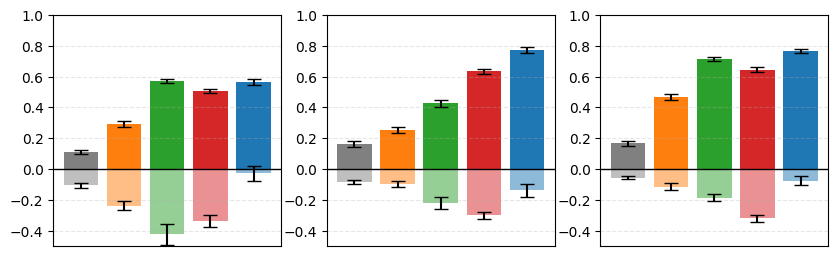

In [ ]:
# [OUTPUT] The displayed output is a preserved historical snapshot; rerun this cell to refresh it.
fig, axes = plt.subplots(1, len(parts), figsize=(12, 3), squeeze=False)
for index, part in enumerate(parts):
    plot_conditional_moran(spatial_summary, part, axes[0, index])
fig.tight_layout()
fig.savefig(f"{output_path}/conditional_moran.pdf", dpi=300)
plt.show()


## 5. Outputs and rerun notes

Part-specific REVISE inputs are written under `results/imputation/<part>/`. Expression and conditional Moran results are written under `output/imputation_benchmark/`. Running the notebook from top to bottom refreshes matching derived files but does not remove stale outputs for methods or parts no longer selected.

In [ ]:
# [OUTPUT] Paths for the prepared inputs and derived benchmark results
output_manifest = {
    "prepared_revise": {
        part: revise_part_path(part) for part in parts
    },
    "expression": metric_output_path,
    "spatial": spatial_output_path,
    "expression_summary": f"{output_path}/expression_mean_summary.csv",
    "spatial_summary": f"{output_path}/conditional_moran_summary.csv",
}